In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from network_idx.eda.correlations import fetch_data_from_bq

In [7]:
# Cell 2 - Fetch and prepare data
tract_df = fetch_data_from_bq()

tract_df_modified = tract_df.copy()
techs = ['copper','cable','fiber']
for tech in techs:
    tract_df_modified[f'{tech}_equal_more_than_100_20_units'] = tract_df_modified[f"{tech}_speed_100_20_only"].add(tract_df_modified[f"{tech}_speed_more_than_100_20"], fill_value=0)

# tract_df_modified['perc_growth_parcels'] = round(tract_df_modified['growth_parcels'] / tract_df_modified['total_parcels'], 2)

cols_to_drop = [
    'estimated_fcc_units',
    'copper_speed_less_than_100_20',
    'copper_speed_100_20_only',
    'copper_speed_more_than_100_20',
    'cable_speed_less_than_100_20',
    'cable_speed_100_20_only',
    'cable_speed_more_than_100_20',
    'fiber_speed_less_than_100_20',
    'fiber_speed_100_20_only',
    'fiber_speed_more_than_100_20',
    'fiber_speed_equal_greater_than_100_20',
    'copper_max_upload_speed',
    'cable_max_upload_speed',
    'fiber_max_upload_speed',
    'total_parcels',
    'growth_parcels',
    'unique_locations',
    'total_flags',
    'flags_minus_greatest',
    'new_clip_count',
    'parcel_split_count',
    'mean_dist_nearest_hotspot_m',
    'mean_dist_nearest_fiber_m'
    ]

tract_df_modified = tract_df_modified.drop(columns=cols_to_drop)

Error: Credentials file not found


/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [8]:
# Create binary indicators for growth features using percentile thresholds
binary_features_p90 = [
    'pre_early_dev_parcels',
    'landuse_change_count',
    'builder_developer_count',
    'building_permit_count'
    ]

# P90 threshold for landuse, builder, permits
for col in binary_features_p90:
    threshold = tract_df_modified[col].quantile(0.90)
    tract_df_modified[f'{col}_bin'] = (tract_df_modified[col] >= threshold).astype(int)
    print(f"{col}: P90 threshold = {threshold}, bin=1 count = {tract_df_modified[f'{col}_bin'].sum()}")

# Two versions for pre_early_dev_parcels: P75 and P90
#p75_thresh = tract_df_modified['pre_early_dev_parcels'].quantile(0.75)
#p90_thresh = tract_df_modified['pre_early_dev_parcels'].quantile(0.90)
#tract_df_modified['pre_early_dev_parcels_bin_p75'] = (tract_df_modified['pre_early_dev_parcels'] >= p75_thresh).astype(int)
#tract_df_modified['pre_early_dev_parcels_bin_p90'] = (tract_df_modified['pre_early_dev_parcels'] >= p90_thresh).astype(int)
#print(f"pre_early_dev_parcels: P75 threshold = {p75_thresh}, bin=1 count = {tract_df_modified['pre_early_dev_parcels_bin_p75'].sum()}")
#print(f"pre_early_dev_parcels: P90 threshold = {p90_thresh}, bin=1 count = {tract_df_modified['pre_early_dev_parcels_bin_p90'].sum()}")

# Drop raw count columns (replaced by binary)
tract_df_modified = tract_df_modified.drop(columns=['pre_early_dev_parcels'] + binary_features_p90)


# Keep only numeric columns for PCA
non_numeric = ['tract_geoid']
feature_cols = [c for c in tract_df_modified.select_dtypes(include='number').columns if c not in non_numeric]
df_features = tract_df_modified[feature_cols].dropna()

print(f"Features for PCA: {len(feature_cols)} columns, {len(df_features)} rows")
print(feature_cols)
print(df_features.info())

pre_early_dev_parcels: P90 threshold = 43.0, bin=1 count = 8591
landuse_change_count: P90 threshold = 8.0, bin=1 count = 8533
builder_developer_count: P90 threshold = 9.0, bin=1 count = 8708
building_permit_count: P90 threshold = 7.0, bin=1 count = 8724
Features for PCA: 21 columns, 50047 rows
['pop_ch_1yr', 'pop_pctch_1yr', 'estimated_census_housing_units', 'cable_location_count', 'cable_provider_count', 'cable_max_download_speed', 'copper_location_count', 'copper_provider_count', 'copper_max_download_speed', 'fiber_location_count', 'fiber_provider_count', 'fiber_max_download_speed', 'median_dist_nearest_hotspot', 'median_dist_nearest_fiber_m', 'copper_equal_more_than_100_20_units', 'cable_equal_more_than_100_20_units', 'fiber_equal_more_than_100_20_units', 'pre_early_dev_parcels_bin', 'landuse_change_count_bin', 'builder_developer_count_bin', 'building_permit_count_bin']
<class 'pandas.DataFrame'>
Index: 50047 entries, 0 to 85477
Data columns (total 21 columns):
 #   Column          

In [9]:
# Cell 3 - Standardize features (PCA requires scaled data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

Components for 80% variance: 13
Components for 90% variance: 16


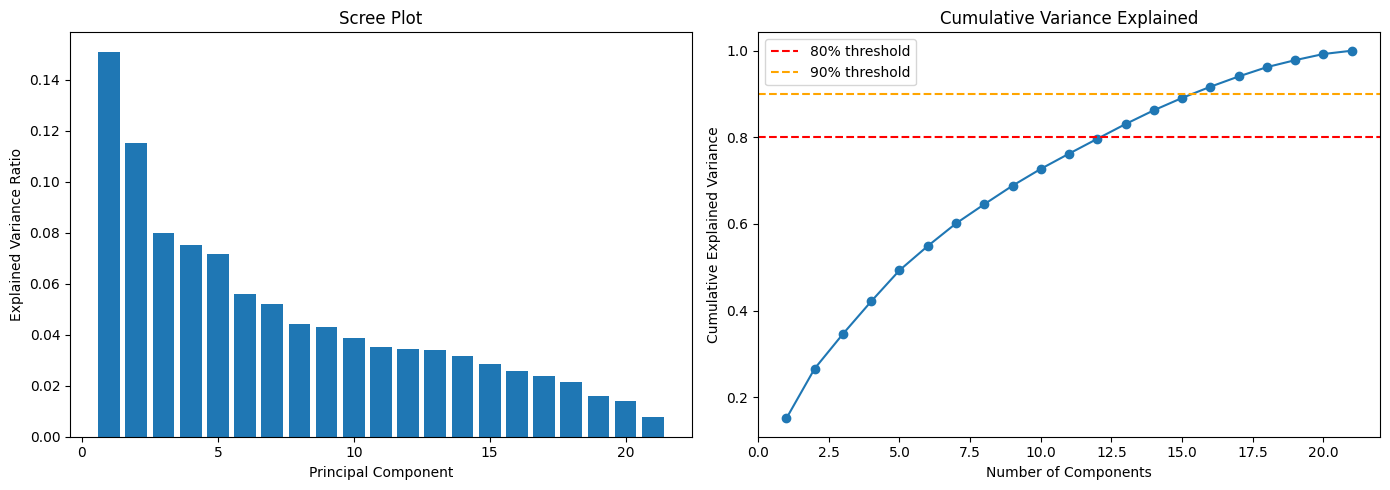

In [10]:
# Principal  Components that explain most of the variance in the data
pca = PCA()
pca.fit(X_scaled)

# Scree plot - explained variance per component
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')

# Cumulative explained variance
cumulative = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker='o')
axes[1].axhline(0.80, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(0.90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()

plt.tight_layout()

# Print how many components needed for 80% and 90%
n_80 = np.argmax(cumulative >= 0.80) + 1
n_90 = np.argmax(cumulative >= 0.90) + 1
print(f"Components for 80% variance: {n_80}")
print(f"Components for 90% variance: {n_90}")

In [11]:
# Examine loadings for the first few components
top_pcas = 12
n_components_to_show = min(top_pcas, len(feature_cols))  # Show top PCs
loadings = pd.DataFrame(
    pca.components_[:n_components_to_show].T,
    columns=[f'PC{i+1}' for i in range(n_components_to_show)],
    index=feature_cols
)

print(f"Loadings shape: {loadings.shape}")
# print top n components loadings
for i in range(n_components_to_show):
    print(f"\nTop features for PC{i+1}:")
    print(loadings[f'PC{i+1}'].abs().sort_values(ascending=False).head(10))
    print("="*60)

Loadings shape: (21, 12)

Top features for PC1:
fiber_location_count                   0.395873
estimated_census_housing_units         0.388448
cable_location_count                   0.380792
builder_developer_count_bin            0.350495
pre_early_dev_parcels_bin              0.330932
building_permit_count_bin              0.253519
copper_location_count                  0.228424
landuse_change_count_bin               0.200099
fiber_provider_count                   0.179146
copper_equal_more_than_100_20_units    0.152374
Name: PC1, dtype: float64

Top features for PC2:
cable_equal_more_than_100_20_units     0.415608
pop_ch_1yr                             0.403031
pop_pctch_1yr                          0.354464
median_dist_nearest_hotspot            0.315320
median_dist_nearest_fiber_m            0.293837
cable_max_download_speed               0.278466
copper_equal_more_than_100_20_units    0.236519
landuse_change_count_bin               0.215533
fiber_provider_count                   

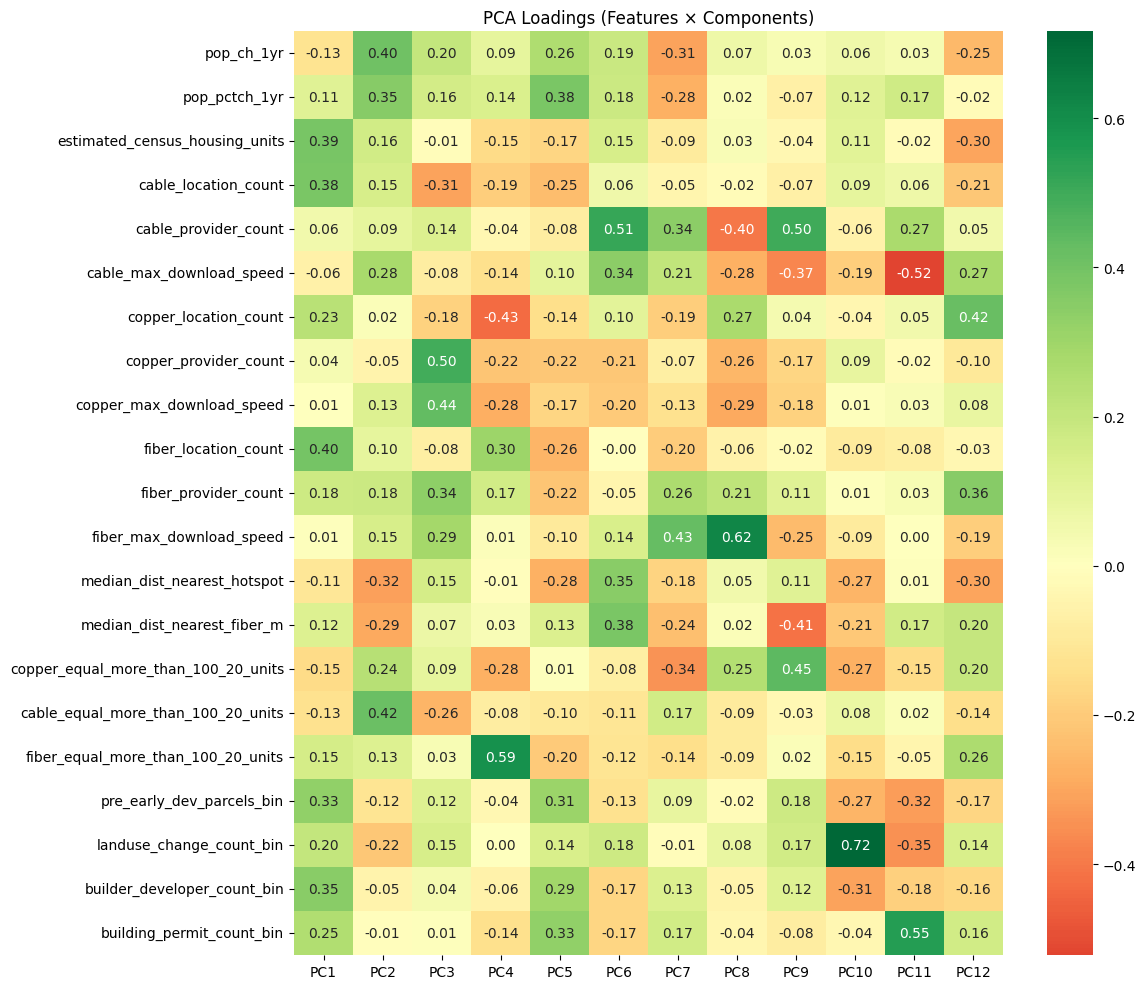

In [12]:
# Heatmap of loadings
fig, ax = plt.subplots(figsize=(12, max(10, len(feature_cols) * 0.4)))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap="RdYlGn", center=0,
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title('PCA Loadings (Features × Components)')
plt.tight_layout()

### PCA Loadings: Feature Classification (Diffuse vs. Concentrated)

| Feature | Classification | Reasoning |
|---------|---------------|-----------|
| `pop_ch_1yr` | Diffuse | Max 0.46 (PC2) but also loads on PC7 (0.30), PC12 (0.27), PC6 (0.23) — spread across 4 components |
| `pop_pctch_1yr` | Diffuse | No single dominant PC; loads 0.37 (PC2), 0.35 (PC7), 0.29 (PC6), 0.26 (PC11) — evenly spread |
| `estimated_census_housing_units` | Moderately Diffuse | Strongest on PC1 (0.41) but also 0.27 (PC12), 0.19 (PC5) — PC1-leaning but not concentrated |
| `cable_location_count` | Diffuse | Loads on PC1 (0.38) and PC3 (0.41) nearly equally, plus PC5 (0.24), PC12 (0.26) — shared across components |
| `cable_provider_count` | Very Diffuse | 0.46 (PC6), 0.48 (PC8), 0.43 (PC7), 0.40 (PC11) — loads moderately on 4+ components with no clear winner |
| `cable_max_download_speed` | Diffuse | 0.47 (PC11), 0.44 (PC12), 0.31 (PC6), 0.30 (PC2) — significant presence on 4 components |
| `copper_location_count` | Moderately Concentrated | Strongest on PC5 (0.46), with secondary on PC12 (0.34) and PC3 (0.26) — PC5 dominates but not overwhelmingly |
| `copper_provider_count` | Moderately Concentrated | Peaks at PC4 (0.44), secondary on PC3 (0.31) — one main component |
| `copper_max_download_speed` | Diffuse | 0.36 (PC4), 0.29 (PC5), 0.28 (PC3) — spread across 3 PCs without a clear dominant one |
| `fiber_location_count` | Diffuse | 0.40 (PC1), 0.25 (PC5), 0.24 (PC3), 0.20 (PC4, PC11) — broadly distributed |
| `fiber_provider_count` | Diffuse | 0.41 (PC4), 0.34 (PC12), 0.25 (PC11), 0.24 (PC7) — no single PC dominates |
| `fiber_max_download_speed` | **Concentrated** | **0.63 on PC8** — clearly owns this component; next highest is 0.41 (PC7), rest ≤0.25 |
| `pre_early_dev_parcels` | Diffuse | 0.36 (PC1), 0.32 (PC3), 0.23 (PC4) — medium loadings split across top PCs |
| `builder_developer_count` | Diffuse | 0.30 (PC1), 0.30 (PC3), 0.26 (PC4), 0.24 (PC10) — uniformly medium, no standout |
| `landuse_change_count` | **Concentrated** | **0.71 on PC9, 0.54 on PC10** — dominates two late components; rest all ≤0.22 |
| `building_permit_count` | Diffuse | 0.31 (PC1), 0.28 (PC3), 0.28 (PC4) — evenly spread, no single component above 0.35 |
| `median_dist_nearest_hotspot` | Very Diffuse | 0.40 (PC11), 0.38 (PC10), 0.31 (PC2), 0.29 (PC6), 0.25 (PC12) — loads on 5 components |
| `median_dist_nearest_fiber_m` | Moderately Concentrated | 0.47 (PC6) is strongest, with 0.31 (PC2), 0.29 (PC9) — one main axis plus secondary |
| `copper_equal_more_than_100_20_units` | Diffuse | 0.48 (PC10), 0.38 (PC9), 0.32 (PC12), 0.28 (PC2, PC5, PC7) — spread across 5+ PCs |
| `cable_equal_more_than_100_20_units` | Diffuse | 0.42 (PC2), 0.26 (PC3), 0.24 (PC11), 0.21 (PC7) — PC2-leaning but not dominant |
| `fiber_equal_more_than_100_20_units` | **Concentrated** | **0.56 on PC5** — clearly strongest; next is 0.26 (PC12), rest ≤0.24 |

### Summary
- **3 clearly concentrated:** `fiber_max_download_speed`, `landuse_change_count`, `fiber_equal_more_than_100_20_units`
- **3 moderately concentrated:** `copper_location_count`, `copper_provider_count`, `median_dist_nearest_fiber_m`
- **15 diffuse:** Everything else — particularly the growth/development features which share a common "development activity" factor